# sklearn model with tensorflow keras tuner

In [ ]:
# ! python -m pip install --no-index --find-links=/kaggle/usr/lib/pip_install_permanent/my_packages -r /kaggle/usr/lib/pip_install_permanent/requirements.txt

In [ ]:
# import os
# os.environ['PACKAGE_DIR'] = '/kaggle/usr/lib/pip_install_permanent'

In [ ]:
import sklearn
print(sklearn.__version__)

In [1]:
from helper_func import *
# # import helper_functions as hf
# import sys
# import nltk
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer
# import string
# from spellchecker import SpellChecker
# from textblob import TextBlob
# from multiprocessing import Pool
# from tqdm import tqdm
# import numpy as np
# import pandas as pd
# # Preprocessing
# from nltk.tokenize import word_tokenize, sent_tokenize
# import operator
# from spellchecker import SpellChecker
# from tqdm import tqdm  # Import tqdm
# import re
# import inflect
# from wordsegment import load, segment
# from nltk.corpus import words
# word_list = set(words.words())
# from spellchecker import SpellChecker

# from tqdm.contrib.concurrent import process_map  # If this import fails, you might need to update tqdm

# import multiprocessing
 
# # Import Packages
# # import shutup; shutup.please()
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import tensorflow as tf
# import keras_tuner as kt
# import seaborn as sns

# from nltk.corpus import stopwords, wordnet
# from nltk.tokenize import word_tokenize, sent_tokenize
# from nltk import pos_tag, ne_chunk
# from textblob import TextBlob

# from textstat import flesch_reading_ease, smog_index

# import spacy
# from collections import Counter
# from gensim import corpora, models
# import pyLDAvis.gensim as gen
# import pyLDAvis
# import re

# # Machine Learning & Data Preprocessing

# from sklearn.preprocessing import StandardScaler, MinMaxScaler
# from sklearn.model_selection import train_test_split
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics.pairwise import cosine_similarity

# # Deep Learning

# from tensorflow.keras import layers
# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences

# # Gensim
# # from gensim.models import Word2Vec, KeyedVectors
# import pandas as pd
# # Progress bar
# from tqdm import tqdm

# # Keras Tuner
# from keras_tuner.tuners import RandomSearch

# # # Setting logging levels and environment variables
# # tf.get_logger().setLevel(logging.ERROR)
# # os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# from textstat import flesch_reading_ease

# # from helper_functions import *
# import nltk
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer
# import string
# from spellchecker import SpellChecker
# from textblob import TextBlob
# from multiprocessing import Pool
# from tqdm import tqdm
# import numpy as np
# import pandas as pd
# # Preprocessing
# from nltk.tokenize import word_tokenize, sent_tokenize
# import operator
# from spellchecker import SpellChecker
# from tqdm import tqdm  # Import tqdm
# import re
# import inflect
# from wordsegment import load, segment
# from nltk.corpus import words
# word_list = set(words.words())
# print('Packages Instaled......')
import sklearn
print(sklearn.__version__)

/home/jack/envs/scoring/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1.2.2


[nltk_data] Downloading package punkt to /home/jack/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jack/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /home/jack/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/jack/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
import sklearn
print(sklearn.__version__)

1.2.2


In [ ]:
# import pandas as pd

# deberta_train = pd.read_csv('/home/jack/github/kaggle/scoring/deberta_train_predictions.csv')
# deberta_val = pd.read_csv('/home/jack/github/kaggle/scoring/deberta_val_predictions.csv')

In [ ]:
# deberta_full = pd.concat([deberta_train, deberta_val])
# deberta_full.head()

In [3]:
deberta_full = pd.read_csv('/home/jack/github/kaggle/scoring/result_df.csv')
deberta_full.drop(columns=['score', 'labels', 'full_text'], inplace=True)
deberta_full.head()

,essay_id,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,...,dep_case,dep_npadvmod,dep_dative,dep_appos,dep_oprd,dep_quantmod,dep_preconj,dep_meta,dep_parataxis,dep_csubjpass
0,000fe60,0.00142,0.07125,0.83951,0.08677,0.00076,0.00029,0.11673,0.16786,0.14917,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,001ab80,0.00156,0.00193,0.03306,0.51663,0.43321,0.01360,0.12119,0.17299,0.15238,...,3.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,002ba53,0.03121,0.38890,0.52278,0.05410,0.00205,0.00096,0.11773,0.17447,0.14637,...,4.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0033037,0.02151,0.95149,0.02577,0.00069,0.00022,0.00032,0.11626,0.17323,0.14944,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0033bf4,0.00071,0.01629,0.57911,0.40089,0.00260,0.00040,0.11823,0.16659,0.15922,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# # drop columns with hash in the name

# hash_cols = [col for col in deberta_full.columns if 'hash' in col]

# deberta_full.drop(columns=hash_cols, inplace=True)

# deberta_full.head()

In [ ]:
# import pandas as pd
# from sklearn.feature_extraction.text import HashingVectorizer


# # Initialize the HashingVectorizer
# n_features = 500  # Number of columns in the hashed vector
# hashing_vectorizer = HashingVectorizer(n_features=n_features, alternate_sign=False)

# # Transform the text column into hash vector features
# hashed_features = hashing_vectorizer.transform(deberta_full['clean_text'])

# # Convert the hashed features to a dense representation for easier manipulation
# hashed_features_dense = hashed_features.todense()

# # Create new column names based on the number of features
# hashed_columns = [f'hash_{i}' for i in range(n_features)]

# # Convert dense representation to a dataframe
# hashed_df = pd.DataFrame(hashed_features_dense, columns=hashed_columns)

# # Concatenate the original dataframe with the hashed dataframe

# deberta_full = pd.concat([deberta_full, hashed_df], axis=1)

In [4]:
deberta_full.tail()

,essay_id,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,...,dep_case,dep_npadvmod,dep_dative,dep_appos,dep_oprd,dep_quantmod,dep_preconj,dep_meta,dep_parataxis,dep_csubjpass
17302,ffb732c,0.00204,0.24010,0.74278,0.01442,0.00036,0.00030,0.11710,0.17367,0.15759,...,0.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
17303,ffc11a8,0.00646,0.32577,0.64545,0.02144,0.00048,0.00040,0.11782,0.16194,0.15561,...,0.0,1.0,2.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0
17304,ffcb061,0.00150,0.03396,0.48995,0.46886,0.00512,0.00061,0.11733,0.17652,0.15410,...,1.0,3.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
17305,ffd378d,0.09231,0.89164,0.01439,0.00074,0.00041,0.00051,0.11830,0.17410,0.15376,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
17306,fffb49b,0.67594,0.29355,0.02541,0.00271,0.00125,0.00114,0.12056,0.16599,0.15436,...,3.0,5.0,0.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0


In [ ]:
# deberta_full = deberta_full.merge(xlnet, on='essay_id', how='left')
# deberta_full.head()

In [ ]:
# deberta_full.tail()

In [ ]:
# deberta_full.drop(columns=[ 'score'], inplace=True)

In [5]:
train = pd.read_csv('/home/jack/github/kaggle/scoring/data/train.csv')

In [6]:
print(deberta_full.shape, train.shape)

(17307, 794) (17307, 3)


In [7]:
# Combine train and deberta_full on essay_id

train = train.merge(deberta_full, on='essay_id')

In [8]:
train.to_parquet('train_with_deberta.parquet')

In [9]:
train.head()

,essay_id,full_text,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,...,dep_case,dep_npadvmod,dep_dative,dep_appos,dep_oprd,dep_quantmod,dep_preconj,dep_meta,dep_parataxis,dep_csubjpass
0,000d118,Many people have car where they live. The thin...,3,0.02153,0.37947,0.52922,0.06692,0.00207,0.00079,0.11885,...,2.0,4.0,1.0,3.0,2.0,2.0,0.0,0.0,0.0,0.0
1,000fe60,I am a scientist at NASA that is discussing th...,3,0.00142,0.07125,0.83951,0.08677,0.00076,0.00029,0.11673,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,001ab80,People always wish they had the same technolog...,4,0.00156,0.00193,0.03306,0.51663,0.43321,0.01360,0.12119,...,3.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,001bdc0,"We all heard about Venus, the planet without a...",4,0.00093,0.00575,0.20694,0.76775,0.01778,0.00085,0.12091,...,4.0,4.0,2.0,2.0,0.0,2.0,0.0,2.0,0.0,0.0
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,0.03121,0.38890,0.52278,0.05410,0.00205,0.00096,0.11773,...,4.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Initialize a CountVectorizer with n-gram range from 1 to 3 (unigrams to trigrams)
vectorizer = CountVectorizer(ngram_range=(1, 3), max_features=500)  # Adjust max_features as needed

# Assuming 'essay' column contains the text data
X_ngrams = vectorizer.fit_transform(train['full_text'])

# Convert the matrix to a DataFrame
df_ngrams = pd.DataFrame(X_ngrams.toarray(), columns=vectorizer.get_feature_names_out())

df = pd.concat([train.reset_index(drop=True), df_ngrams.reset_index(drop=True)], axis=1)
df.tail()

,essay_id,full_text,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,...,would,would be,would have,wrong,years,you,you are,you can,you have,your
17302,ffd378d,"the story "" The Challenge of Exploing Venus "" ...",2,0.09231,0.89164,0.01439,0.00074,0.00041,0.00051,0.11830,...,1,1,0,0,0,0,0,0,0,0
17303,ffddf1f,Technology has changed a lot of ways that we l...,4,0.00101,0.00522,0.19799,0.71123,0.08232,0.00223,0.11987,...,0,0,0,1,1,2,0,0,0,2
17304,fff016d,If you don't like sitting around all day than ...,2,0.04347,0.93561,0.01935,0.00080,0.00030,0.00047,0.11671,...,0,0,0,0,0,16,1,0,1,1
17305,fffb49b,"In ""The Challenge of Exporing Venus,"" the auth...",1,0.67594,0.29355,0.02541,0.00271,0.00125,0.00114,0.12056,...,0,0,0,0,0,0,0,0,0,0
17306,fffed3e,Venus is worthy place to study but dangerous. ...,2,0.13117,0.85749,0.00953,0.00075,0.00041,0.00064,0.11845,...,0,0,0,0,0,2,0,0,1,1


In [11]:
import pickle

# Save the vectorizer to a file
with open('vectorizer.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)


In [13]:
import spacy
import pandas as pd
import pickle


# Load a spaCy model
nlp = spacy.load("en_core_web_sm")

# Function to extract all possible tags from a series of texts
def extract_all_possible_tags(series, attribute):
    all_tags = set()
    for text in series:
        doc = nlp(text)
        tags = doc.count_by(attribute)
        all_tags.update([doc.vocab.strings[tag] for tag in tags])
    return all_tags



# Define function to count attributes with preset tags
def count_attributes(text, attribute, all_tags):
    doc = nlp(text)
    counts = doc.count_by(attribute)
    # Initialize all tag counts to 0
    tag_dict = {tag: 0 for tag in all_tags}
    # Update the dictionary with actual counts
    for tag_id, count in counts.items():
        tag = doc.vocab.strings[tag_id]
        if tag in tag_dict:
            tag_dict[tag] = count
    return tag_dict


# Collect all tags using the training data
all_pos_tags = extract_all_possible_tags(train['full_text'], spacy.attrs.POS)
all_entity_types = extract_all_possible_tags(train['full_text'], spacy.attrs.ENT_TYPE)
all_dep_tags = extract_all_possible_tags(train['full_text'], spacy.attrs.DEP)

# Serialize and save the tags
with open('pos_tags.pkl', 'wb') as f:
    pickle.dump(all_pos_tags, f)
with open('entity_types.pkl', 'wb') as f:
    pickle.dump(all_entity_types, f)
with open('dep_tags.pkl', 'wb') as f:
    pickle.dump(all_dep_tags, f)
    

In [14]:
    
# Function to extract features based on the loaded tags
def extract_features(df, pos_tags, entity_types, dep_tags):
    # Apply feature extraction for POS
    df_pos_features = pd.DataFrame(df['full_text'].apply(lambda x: count_attributes(x, spacy.attrs.POS, pos_tags)).tolist())
    df_pos_features.columns = [f'pos_{col}' for col in df_pos_features.columns]

    # Apply feature extraction for Named Entities
    df_entity_features = pd.DataFrame(df['full_text'].apply(lambda x: count_attributes(x, spacy.attrs.ENT_TYPE, entity_types)).tolist())
    df_entity_features.columns = [f'ner_{col}' for col in df_entity_features.columns]

    # Apply feature extraction for Dependency Tags
    df_dep_features = pd.DataFrame(df['full_text'].apply(lambda x: count_attributes(x, spacy.attrs.DEP, dep_tags)).tolist())
    df_dep_features.columns = [f'dep_{col}' for col in df_dep_features.columns]

    # Concatenate all new feature DataFrames back to the original DataFrame
    df_extended = pd.concat([df, df_pos_features, df_entity_features, df_dep_features], axis=1)
    return df_extended

In [15]:
# Assuming df is your DataFrame with the column 'full_text'
df = extract_features(df, all_pos_tags, all_entity_types, all_dep_tags)

df.head()

,essay_id,full_text,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,...,dep_acl,dep_csubj,dep_prep,dep_mark,dep_acomp,dep_cc,dep_case,dep_appos,dep_advmod,dep_nsubj
0,000d118,Many people have car where they live. The thin...,3,0.02153,0.37947,0.52922,0.06692,0.00207,0.00079,0.11885,...,2,1,52,22,6,19,2,3,21,59
1,000fe60,I am a scientist at NASA that is discussing th...,3,0.00142,0.07125,0.83951,0.08677,0.00076,0.00029,0.11673,...,2,1,35,7,3,9,0,0,26,44
2,001ab80,People always wish they had the same technolog...,4,0.00156,0.00193,0.03306,0.51663,0.43321,0.01360,0.12119,...,1,1,49,17,11,16,3,0,46,59
3,001bdc0,"We all heard about Venus, the planet without a...",4,0.00093,0.00575,0.20694,0.76775,0.01778,0.00085,0.12091,...,7,1,50,13,2,21,4,2,20,38
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,0.03121,0.38890,0.52278,0.05410,0.00205,0.00096,0.11773,...,1,1,50,8,7,9,4,1,10,32


In [16]:
train = df.copy()

In [ ]:
# import os
# from tqdm import tqdm

# glove_path = 'data/glove-840B-300d.txt'

# paragram_path = '/home/jack/github/kaggle/scoring/data/paragram-300-sl999.txt'

# wiki_news_path = 'data/wiki-news-1M-300d.vec'


# # Load embeddings

# embeddings = parallel_load_embeddings([glove_path, paragram_path, wiki_news_path])

# glove = embeddings["glove"]
# paragram = embeddings["paragram"]
# fasttext = embeddings["fasttext"]

In [ ]:
# train, oov_glove, oov_paragram, oov_fasttxt = spellcheck_and_correct_text(train, embeddings)

In [ ]:
# train.to_parquet('train_full_clean_process.parquet')

In [17]:
train = clean_text(train)

train.head()

Starting text cleaning process. 

Adding Text Features................. 

Complete................. 



,essay_id,full_text,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,...,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,min_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score
0,000d118,Many people have car where they live. The thin...,3,0.02153,0.37947,0.52922,0.06692,0.00207,0.00079,0.11885,...,498,38.307692,127,7,4.369478,25,1,57.98,17.33,0.9937
1,000fe60,I am a scientist at NASA that is discussing th...,3,0.00142,0.07125,0.83951,0.08677,0.00076,0.00029,0.11673,...,37,15.809524,48,2,4.018072,11,1,87.55,7.48,0.7705
2,001ab80,People always wish they had the same technolog...,4,0.00156,0.00193,0.03306,0.51663,0.43321,0.01360,0.12119,...,85,22.916667,46,9,4.574545,15,1,65.15,11.49,-0.9731
3,001bdc0,"We all heard about Venus, the planet without a...",4,0.00093,0.00575,0.20694,0.76775,0.01778,0.00085,0.12091,...,25,22.550000,38,5,4.982262,20,1,58.32,11.91,0.9702
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,0.03121,0.38890,0.52278,0.05410,0.00205,0.00096,0.11773,...,2,24.933333,76,2,4.873995,14,1,54.66,12.64,0.9771


In [18]:
def custom_train_validation_split(essays, test_size=0.2, random_state=56):
    
    """
    Custom function to perform train-validation split ensuring that
    the same prompt IDs are in both training and validation sets.

    Parameters:
    - summaries: DataFrame containing summaries and associated prompt_ids
    - prompts: DataFrame containing prompts and associated prompt_ids
    - test_size: Proportion of the dataset to be used as the validation set
    - random_state: Random seed for reproducibility

    Returns:
    - train_summaries: Training set containing summaries
    - validation_summaries: Validation set containing summaries
    - train_prompts: Training set containing prompts
    - validation_prompts: Validation set containing prompts
    """

    from sklearn.model_selection import train_test_split

    
    # Extract unique prompt IDs
    unique_essay_ids = essays['essay_id'].unique()

    # Split the unique prompt IDs into training and validation sets
    train_ids, validation_ids = train_test_split(unique_essay_ids, test_size=test_size, random_state=random_state)

    # Use these IDs to filter the original summaries and prompts DataFrames
    train_essays = essays[essays['essay_id'].isin(train_ids)]
    validation_essays = essays[essays['essay_id'].isin(validation_ids)]

    return train_essays, validation_essays

In [19]:
train_essays, val_essays = custom_train_validation_split(train, test_size=0.25, random_state=42)

In [20]:
train_essays.head()

,essay_id,full_text,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,...,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,min_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score
1,000fe60,I am a scientist at NASA that is discussing th...,3,0.00142,0.07125,0.83951,0.08677,0.00076,0.00029,0.11673,...,37,15.809524,48,2,4.018072,11,1,87.55,7.48,0.7705
2,001ab80,People always wish they had the same technolog...,4,0.00156,0.00193,0.03306,0.51663,0.43321,0.01360,0.12119,...,85,22.916667,46,9,4.574545,15,1,65.15,11.49,-0.9731
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,0.03121,0.38890,0.52278,0.05410,0.00205,0.00096,0.11773,...,2,24.933333,76,2,4.873995,14,1,54.66,12.64,0.9771
6,0033037,The posibilty of a face reconizing computer wo...,2,0.02151,0.95149,0.02577,0.00069,0.00022,0.00032,0.11626,...,40,25.571429,42,15,4.754190,13,1,62.61,13.08,0.1245
7,0033bf4,What is the Seagoing Cowboys progam?\n\nIt was...,3,0.00071,0.01629,0.57911,0.40089,0.00260,0.00040,0.11823,...,5,13.576923,34,5,4.569405,15,1,83.15,6.20,0.9962


In [21]:
# import pandas as pd

# train_essays = pd.read_parquet('/home/jack/github/kaggle/scoring/train_essays.parquet')
# val_essays = pd.read_parquet('/home/jack/github/kaggle/scoring/validation_essays.parquet')

In [22]:
pd.set_option('display.max_columns', None)

train_essays.head()

,essay_id,full_text,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,able,able to,about,about the,accidents,action,action coding,action coding system,actually,after,air,alien,aliens,all,all of,all the,also,always,amount,an,and,and it,and that,and the,and they,animals,another,any,anything,are,are not,around,article,as,as the,at,at the,atmosphere,attention,author,away,back,bad,be,be able,be able to,be the,because,because it,because of,because the,because they,become,been,before,being,believe,believe that,best,better,big,bored,but,but it,by,by the,called,can,can be,candidate,car,car usage,cars,cars are,cause,change,city,classroom,close,coding,coding system,college,college is,come,computer,computers,conclusion,conditions,confused,control,could,could be,country,cowboy,cowboys,created,dangerous,dangers,day,despite,did,different,do,do not,does,doing,don,dont,down,drive,driver,driverless,driverless car,driverless cars,driverless cars are,drivers,driving,due,due to,each,earth,election,electoral,electoral college,electoral college is,electors,emotion,emotions,enough,even,ever,every,everyone,evidence,example,exploring,expressions,face,face on,face on mars,facial,facial action,facial action coding,fact,feel,feeling,few,find,first,for,for example,for the,free,from,from the,fun,future,gas,get,get to,getting,give,go,going,going to,good,got,great,had,happen,happy,hard,has,has been,have,have been,have to,having,he,help,his,how,however,human,humans,idea,if,if the,if they,if we,if you,important,in,in conclusion,in our,in paragraph,in the,in the article,in this,information,into,is,is just,is not,is that,is the,is very,it,it can,it could,it is,it was,it will,it would,it would be,its,join,just,keep,know,landform,learn,less,lesson,life,like,limiting,live,long,look,lot,lot of,luke,made,make,makes,making,many,many people,mars,may,maybe,me,means,mesa,might,money,more,most,much,my,nasa,natural,natural landform,need,need to,needs,never,new,no,not,not be,not only,now,of,of the,of this,of venus,off,on,on earth,on mars,on the,once,one,one of,only,or,other,others,our,out,out of,over,own,paragraph,paris,people,percent,person,picture,place,places,planet,point,pollution,popular,pop

In [23]:
train_essays['score'].value_counts()

score
3    4706
2    3517
4    2988
1     926
5     731
6     112
Name: count, dtype: int64

In [24]:
drop_cols = [ 'full_text', 'clean_text' , 'lowered', 'min_word_length'] # , 'combined_dense_vector']   


train_df = train_essays.copy()
val_df = val_essays.copy()

train_df.drop(columns=drop_cols, inplace= True)
val_df.drop(columns=drop_cols, inplace= True)


In [25]:
train_df.head()

,essay_id,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,able,able to,about,about the,accidents,action,action coding,action coding system,actually,after,air,alien,aliens,all,all of,all the,also,always,amount,an,and,and it,and that,and the,and they,animals,another,any,anything,are,are not,around,article,as,as the,at,at the,atmosphere,attention,author,away,back,bad,be,be able,be able to,be the,because,because it,because of,because the,because they,become,been,before,being,believe,believe that,best,better,big,bored,but,but it,by,by the,called,can,can be,candidate,car,car usage,cars,cars are,cause,change,city,classroom,close,coding,coding system,college,college is,come,computer,computers,conclusion,conditions,confused,control,could,could be,country,cowboy,cowboys,created,dangerous,dangers,day,despite,did,different,do,do not,does,doing,don,dont,down,drive,driver,driverless,driverless car,driverless cars,driverless cars are,drivers,driving,due,due to,each,earth,election,electoral,electoral college,electoral college is,electors,emotion,emotions,enough,even,ever,every,everyone,evidence,example,exploring,expressions,face,face on,face on mars,facial,facial action,facial action coding,fact,feel,feeling,few,find,first,for,for example,for the,free,from,from the,fun,future,gas,get,get to,getting,give,go,going,going to,good,got,great,had,happen,happy,hard,has,has been,have,have been,have to,having,he,help,his,how,however,human,humans,idea,if,if the,if they,if we,if you,important,in,in conclusion,in our,in paragraph,in the,in the article,in this,information,into,is,is just,is not,is that,is the,is very,it,it can,it could,it is,it was,it will,it would,it would be,its,join,just,keep,know,landform,learn,less,lesson,life,like,limiting,live,long,look,lot,lot of,luke,made,make,makes,making,many,many people,mars,may,maybe,me,means,mesa,might,money,more,most,much,my,nasa,natural,natural landform,need,need to,needs,never,new,no,not,not be,not only,now,of,of the,of this,of venus,off,on,on earth,on mars,on the,once,one,one of,only,or,other,others,our,out,out of,over,own,paragraph,paris,people,percent,person,picture,place,places,planet,point,pollution,popular,popular vote,

In [26]:
feature_cols = []

for col in train_df.columns:
    if (col != 'essay_id') and (col != 'score'):
        feature_cols.append(col) 

In [27]:
pd.set_option('display.max_columns', None)
feature_cols

['deberta_prob_0',
 'deberta_prob_1',
 'deberta_prob_2',
 'deberta_prob_3',
 'deberta_prob_4',
 'deberta_prob_5',
 'xlnet_prob_0',
 'xlnet_prob_1',
 'xlnet_prob_2',
 'xlnet_prob_3',
 'xlnet_prob_4',
 'xlnet_prob_5',
 'hash_0',
 'hash_1',
 'hash_2',
 'hash_3',
 'hash_4',
 'hash_5',
 'hash_6',
 'hash_7',
 'hash_8',
 'hash_9',
 'hash_10',
 'hash_11',
 'hash_12',
 'hash_13',
 'hash_14',
 'hash_15',
 'hash_16',
 'hash_17',
 'hash_18',
 'hash_19',
 'hash_20',
 'hash_21',
 'hash_22',
 'hash_23',
 'hash_24',
 'hash_25',
 'hash_26',
 'hash_27',
 'hash_28',
 'hash_29',
 'hash_30',
 'hash_31',
 'hash_32',
 'hash_33',
 'hash_34',
 'hash_35',
 'hash_36',
 'hash_37',
 'hash_38',
 'hash_39',
 'hash_40',
 'hash_41',
 'hash_42',
 'hash_43',
 'hash_44',
 'hash_45',
 'hash_46',
 'hash_47',
 'hash_48',
 'hash_49',
 'hash_50',
 'hash_51',
 'hash_52',
 'hash_53',
 'hash_54',
 'hash_55',
 'hash_56',
 'hash_57',
 'hash_58',
 'hash_59',
 'hash_60',
 'hash_61',
 'hash_62',
 'hash_63',
 'hash_64',
 'hash_65',
 '

In [28]:
# save the order of the column names to a txt file

with open('feature_cols.txt', 'w') as f:
    for item in feature_cols:
        f.write("%s\n" % item)

In [29]:
# # read in the feature columns

# with open('feature_cols.txt', 'r') as f:
#     feature_cols = f.read().splitlines()

In [30]:
# !pip install scikit-learn==1.2.2

In [31]:
import sklearn
print(sklearn.__version__)

1.2.2


In [32]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
import numpy as np

# Extract labels from the training and validation datasets
train_labels = train_df['score']  # Extracts 'score' column as the label
val_labels = val_df['score']

# Extract features for scaling
train_features = train_df[feature_cols] # Subset with only feature columns
val_features = val_df[feature_cols]

# Initialize the scaler
scaler = MinMaxScaler()  # Using StandardScaler for scaling

# Fit the scaler to the training features
scaler.fit(train_features)  # This defines the transformation based on the training data

# Transform training and validation features
train_feats_scaled = scaler.transform(train_features)  # Transforms the training data
val_feats_scaled = scaler.transform(val_features)  # Transforms the validation data

# Reassign the scaled features to the original DataFrames, keeping the same column names
train_df[feature_cols] = train_feats_scaled  # Replace the original features with scaled ones
val_df[feature_cols] = val_feats_scaled

# Save the scaler for later use
with open('sklearn_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)  # Persist the scaler for future use or reference


In [33]:
# Check if the file has been written correctly and is not empty
import os
scaler_path = 'sklearn_scaler.pkl'
if os.path.getsize(scaler_path) > 0:
    print(f"Scaler saved successfully in {scaler_path}.")
else:
    print(f"Failed to save scaler to {scaler_path}. File is empty.")

Scaler saved successfully in sklearn_scaler.pkl.


In [34]:
# Check if the scaler is StandardScaler
if isinstance(scaler, StandardScaler):
    print("The scaler is a StandardScaler.")
elif isinstance(scaler, MinMaxScaler):
    print("The scaler is a MinMaxScaler.")
else:
    print("The scaler is neither StandardScaler nor MinMaxScaler.")

The scaler is a MinMaxScaler.


In [35]:
# train_df = pca_dataframe(train_df)
# val_df = pca_dataframe(val_df)

In [36]:
train_df.head()

,essay_id,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,able,able to,about,about the,accidents,action,action coding,action coding system,actually,after,air,alien,aliens,all,all of,all the,also,always,amount,an,and,and it,and that,and the,and they,animals,another,any,anything,are,are not,around,article,as,as the,at,at the,atmosphere,attention,author,away,back,bad,be,be able,be able to,be the,because,because it,because of,because the,because they,become,been,before,being,believe,believe that,best,better,big,bored,but,but it,by,by the,called,can,can be,candidate,car,car usage,cars,cars are,cause,change,city,classroom,close,coding,coding system,college,college is,come,computer,computers,conclusion,conditions,confused,control,could,could be,country,cowboy,cowboys,created,dangerous,dangers,day,despite,did,different,do,do not,does,doing,don,dont,down,drive,driver,driverless,driverless car,driverless cars,driverless cars are,drivers,driving,due,due to,each,earth,election,electoral,electoral college,electoral college is,electors,emotion,emotions,enough,even,ever,every,everyone,evidence,example,exploring,expressions,face,face on,face on mars,facial,facial action,facial action coding,fact,feel,feeling,few,find,first,for,for example,for the,free,from,from the,fun,future,gas,get,get to,getting,give,go,going,going to,good,got,great,had,happen,happy,hard,has,has been,have,have been,have to,having,he,help,his,how,however,human,humans,idea,if,if the,if they,if we,if you,important,in,in conclusion,in our,in paragraph,in the,in the article,in this,information,into,is,is just,is not,is that,is the,is very,it,it can,it could,it is,it was,it will,it would,it would be,its,join,just,keep,know,landform,learn,less,lesson,life,like,limiting,live,long,look,lot,lot of,luke,made,make,makes,making,many,many people,mars,may,maybe,me,means,mesa,might,money,more,most,much,my,nasa,natural,natural landform,need,need to,needs,never,new,no,not,not be,not only,now,of,of the,of this,of venus,off,on,on earth,on mars,on the,once,one,one of,only,or,other,others,our,out,out of,over,own,paragraph,paris,people,percent,person,picture,place,places,planet,point,pollution,popular,popular vote,

In [37]:
val_df.head()

,essay_id,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,able,able to,about,about the,accidents,action,action coding,action coding system,actually,after,air,alien,aliens,all,all of,all the,also,always,amount,an,and,and it,and that,and the,and they,animals,another,any,anything,are,are not,around,article,as,as the,at,at the,atmosphere,attention,author,away,back,bad,be,be able,be able to,be the,because,because it,because of,because the,because they,become,been,before,being,believe,believe that,best,better,big,bored,but,but it,by,by the,called,can,can be,candidate,car,car usage,cars,cars are,cause,change,city,classroom,close,coding,coding system,college,college is,come,computer,computers,conclusion,conditions,confused,control,could,could be,country,cowboy,cowboys,created,dangerous,dangers,day,despite,did,different,do,do not,does,doing,don,dont,down,drive,driver,driverless,driverless car,driverless cars,driverless cars are,drivers,driving,due,due to,each,earth,election,electoral,electoral college,electoral college is,electors,emotion,emotions,enough,even,ever,every,everyone,evidence,example,exploring,expressions,face,face on,face on mars,facial,facial action,facial action coding,fact,feel,feeling,few,find,first,for,for example,for the,free,from,from the,fun,future,gas,get,get to,getting,give,go,going,going to,good,got,great,had,happen,happy,hard,has,has been,have,have been,have to,having,he,help,his,how,however,human,humans,idea,if,if the,if they,if we,if you,important,in,in conclusion,in our,in paragraph,in the,in the article,in this,information,into,is,is just,is not,is that,is the,is very,it,it can,it could,it is,it was,it will,it would,it would be,its,join,just,keep,know,landform,learn,less,lesson,life,like,limiting,live,long,look,lot,lot of,luke,made,make,makes,making,many,many people,mars,may,maybe,me,means,mesa,might,money,more,most,much,my,nasa,natural,natural landform,need,need to,needs,never,new,no,not,not be,not only,now,of,of the,of this,of venus,off,on,on earth,on mars,on the,once,one,one of,only,or,other,others,our,out,out of,over,own,paragraph,paris,people,percent,person,picture,place,places,planet,point,pollution,popular,popular vote,

In [38]:
# train_df.to_parquet('train_df.parquet')
# val_df.to_parquet('val_df.parquet')

In [39]:
import pandas as pd
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

df = train_df.copy()
# Downsample majority classes to 1,000 samples
target_samples = 1000
balanced_df = pd.DataFrame()

for class_label in df['score'].unique():
    class_subset = df[df['score'] == class_label]
    
    if len(class_subset) > target_samples:
        # Downsample to 1,000 samples for majority classes
        class_subset = resample(
            class_subset,
            replace=False,
            n_samples=target_samples,
            random_state=42
        )
    
    balanced_df = pd.concat([balanced_df, class_subset], axis=0)

# Now, let's apply SMOTE to balance the minority classes up to 1,000 samples
X = balanced_df.drop(columns = ['essay_id','score'], axis=1)
y = balanced_df['score']

# Create SMOTE instance to ensure all classes have 1,000 samples
smote = SMOTE(sampling_strategy={k: 1000 for k in y.unique()}, random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

# Create the resampled DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['score'] = y_resampled

# Display the resampled class distribution to confirm the balancing
print("Resampled class distribution:")
print(df_resampled['score'].value_counts())


Resampled class distribution:
score
3    1000
4    1000
2    1000
1    1000
5    1000
6    1000
Name: count, dtype: int64


/tmp/ipykernel_234919/557032744.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_resampled['score'] = y_resampled


In [40]:
UPSAMPLE = False

if UPSAMPLE:
    
    # Balance only the training DataFrame
    train_df = df_resampled.copy()

    
else:
    pass

print(train_df['score'].value_counts())
print(val_df['score'].value_counts())

score
3    4706
2    3517
4    2988
1     926
5     731
6     112
Name: count, dtype: int64
score
3    1574
2    1206
4     938
1     326
5     239
6      44
Name: count, dtype: int64


In [41]:
train_df.head()

,essay_id,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,able,able to,about,about the,accidents,action,action coding,action coding system,actually,after,air,alien,aliens,all,all of,all the,also,always,amount,an,and,and it,and that,and the,and they,animals,another,any,anything,are,are not,around,article,as,as the,at,at the,atmosphere,attention,author,away,back,bad,be,be able,be able to,be the,because,because it,because of,because the,because they,become,been,before,being,believe,believe that,best,better,big,bored,but,but it,by,by the,called,can,can be,candidate,car,car usage,cars,cars are,cause,change,city,classroom,close,coding,coding system,college,college is,come,computer,computers,conclusion,conditions,confused,control,could,could be,country,cowboy,cowboys,created,dangerous,dangers,day,despite,did,different,do,do not,does,doing,don,dont,down,drive,driver,driverless,driverless car,driverless cars,driverless cars are,drivers,driving,due,due to,each,earth,election,electoral,electoral college,electoral college is,electors,emotion,emotions,enough,even,ever,every,everyone,evidence,example,exploring,expressions,face,face on,face on mars,facial,facial action,facial action coding,fact,feel,feeling,few,find,first,for,for example,for the,free,from,from the,fun,future,gas,get,get to,getting,give,go,going,going to,good,got,great,had,happen,happy,hard,has,has been,have,have been,have to,having,he,help,his,how,however,human,humans,idea,if,if the,if they,if we,if you,important,in,in conclusion,in our,in paragraph,in the,in the article,in this,information,into,is,is just,is not,is that,is the,is very,it,it can,it could,it is,it was,it will,it would,it would be,its,join,just,keep,know,landform,learn,less,lesson,life,like,limiting,live,long,look,lot,lot of,luke,made,make,makes,making,many,many people,mars,may,maybe,me,means,mesa,might,money,more,most,much,my,nasa,natural,natural landform,need,need to,needs,never,new,no,not,not be,not only,now,of,of the,of this,of venus,off,on,on earth,on mars,on the,once,one,one of,only,or,other,others,our,out,out of,over,own,paragraph,paris,people,percent,person,picture,place,places,planet,point,pollution,popular,popular vote,

In [42]:
# To convert features and targets to NumPy arrays for ML use

if UPSAMPLE:
    train_features = train_df.drop(columns=['score'], axis=1).values
    train_labels = train_df['score'].values

    val_features = val_df.drop(columns=['essay_id','score'], axis=1).values
    val_labels = val_df['score'].values

else:
    
    train_features = train_df.drop(columns=['essay_id','score'], axis=1).values
    train_labels = train_df['score'].values

    val_features = val_df.drop(columns=['essay_id','score'], axis=1).values
    val_labels = val_df['score'].values


print("Features shape:", train_features.shape)
print("Target shape:", train_labels.shape)

print("Features shape:", val_features.shape)
print("Target shape:", val_labels.shape)

Features shape: (12980, 1389)
Target shape: (12980,)
Features shape: (4327, 1389)
Target shape: (4327,)


In [43]:
from sklearn.metrics import make_scorer, cohen_kappa_score

def quadratic_weighted_kappa_scorer(y_true, y_pred):
    """
    Compute the Quadratic Weighted Kappa (QWK), also known as Cohen's kappa.
    
    Parameters:
    y_true : array-like of shape (n_samples,)
        True labels.
    y_pred : array-liimport keras_tuner
from sklearn import ensemble
from sklearn import datasets
from sklearn import linear_model
from sklearn import metrics
from sklearn import model_selection

def build_model(hp):
  model_type = hp.Choice('model_type', ['random_forest', 'ridge'])
  if model_type == 'random_forest':
    model = ensemble.RandomForestClassifier(
        n_estimators=hp.Int('n_estimators', 10, 50, step=10),
        max_depth=hp.Int('max_depth', 3, 10))
  else:
    model = linear_model.RidgeClassifier(
        alpha=hp.Float('alpha', 1e-3, 1, sampling='log'))
  return model

tuner = keras_tuner.tuners.SklearnTuner(
    oracle=keras_tuner.oracles.BayesianOptimizationOracle(
        objective=keras_tuner.Objective('score', 'max'),
        max_trials=100),
    hypermodel=build_model,
    scoring=metrics.make_scorer(metrics.accuracy_score),
    cv=model_selection.StratifiedKFold(10),
    directory='.',
    project_name='my_project')ke of shape (n_samples,)
        Predicted labels.
    
    Returns:
    score : float
        Quadratic Weighted Kappa score.
    """
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')


In [44]:
# from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
# import keras_tuner as kt

# model_checkpoint = ModelCheckpoint('data/models/best_standard_model_epoch.keras', 
#                                    save_best_only=True, monitor='val_loss', mode='min')

# early_stopping = EarlyStopping(monitor='val_loss', patience=5, 
#                                restore_best_weights=True)

# call_backs = [model_checkpoint, early_stopping]

In [45]:
import keras_tuner
from sklearn import ensemble, linear_model, model_selection, svm
from lightgbm import LGBMClassifier


def build_model(hp):
    """
    Builds a more comprehensive machine learning model based on hyperparameters for multiclass classification.
    
    Parameters:
    hp : HyperParameters
        Hyperparameters for tuning the model.
    
    Returns:
    model : An instance of a Scikit-learn model.
    """
    # Adding 'lightgbm' as a new model type
    model_type = hp.Choice('model_type', ['random_forest',  'gradient_boosting', 'lightgbm'])

    if model_type == 'random_forest':
        model = ensemble.RandomForestClassifier(
            n_estimators=hp.Int('n_estimators', 10, 100, step=10),
            max_depth=hp.Int('max_depth', 3, 20),
            min_samples_split=hp.Int('min_samples_split', 2, 20),
            min_samples_leaf=hp.Int('min_samples_leaf', 1, 10),
            criterion=hp.Choice('criterion', ['gini', 'entropy']),
            class_weight=hp.Choice('class_weight', ['balanced', 'balanced_subsample']),
            max_samples=hp.Float('max_samples', 0.1, 1.0, sampling='log')
        )



    elif model_type == 'gradient_boosting':
        model = ensemble.GradientBoostingClassifier(
            n_estimators=hp.Int('n_estimators', 50, 200, step=50),
            learning_rate=hp.Float('learning_rate', 0.01, 0.2, sampling='log'),
            max_depth=hp.Int('max_depth', 3, 15),
            subsample=hp.Float('subsample', 0.5, 1.0, step=0.1)
        )

    # Adding LightGBM as a new model type
    elif model_type == 'lightgbm':
        model = LGBMClassifier(
            n_estimators=hp.Int('n_estimators', 50, 200, step=50),
            num_leaves=hp.Int('num_leaves', 31, 127, step=16),
            learning_rate=hp.Float('learning_rate', 0.01, 0.2, sampling='log'),
            min_child_samples=hp.Int('min_child_samples', 10, 50, step=10),
            class_weight=hp.Choice('class_weight', ['balanced', 'balanced_sample']),
        )

    return model


# Defining the custom QWK scorer
qwk_scorer = make_scorer(quadratic_weighted_kappa_scorer)

# Tuner configuration
tuner = keras_tuner.tuners.SklearnTuner(
    oracle=keras_tuner.oracles.BayesianOptimizationOracle(
        objective=keras_tuner.Objective('score', 'max'),
        max_trials=30),
    hypermodel=build_model,
    scoring=qwk_scorer,
    cv=model_selection.StratifiedKFold(3),
    directory='.',
    project_name='data/sklearn',
    overwrite=True)

# Starting the search
tuner.search(train_features, train_labels)      # class_weight=class_weights_dict,

# Retrieving the best model
best_model = tuner.get_best_models(num_models=1)[0]


Trial 30 Complete [00h 00m 00s]

Best score So Far: 0.9000670002642317
Total elapsed time: 04h 57m 00s


In [46]:
best_model.fit(train_features, train_labels)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.054598 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76440
[LightGBM] [Info] Number of data points in the train set: 12980, number of used features: 1389
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791760
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(class_weight='balanced', learning_rate=0.02564698362727919,
               min_child_samples=10, n_estimators=70, num_leaves=79)

In [47]:
predictions = best_model.predict(val_features)

y_true = val_labels

# predictions = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()


In [48]:
# confusion matrix

from sklearn.metrics import confusion_matrix

confusion_matrix(y_true, predictions)

array([[ 291,   32,    2,    1,    0,    0],
       [  46, 1016,  137,    7,    0,    0],
       [   3,  139, 1238,  190,    2,    2],
       [   1,    4,  134,  699,  100,    0],
       [   0,    0,    0,   51,  171,   17],
       [   0,    0,    0,    1,   11,   32]])

In [49]:
# classification report

from sklearn.metrics import classification_report

print(classification_report(y_true, predictions))

              precision    recall  f1-score   support

           1       0.85      0.89      0.87       326
           2       0.85      0.84      0.85      1206
           3       0.82      0.79      0.80      1574
           4       0.74      0.75      0.74       938
           5       0.60      0.72      0.65       239
           6       0.63      0.73      0.67        44

    accuracy                           0.80      4327
   macro avg       0.75      0.78      0.77      4327
weighted avg       0.80      0.80      0.80      4327



In [50]:
# cohens kappa

from sklearn.metrics import cohen_kappa_score

cohen = cohen_kappa_score(y_true, predictions)

In [51]:
# quadratic weighted kappa

from sklearn.metrics import cohen_kappa_score

quadratic = cohen_kappa_score(y_true, predictions, weights='quadratic')

print(f"Cohen's Kappa: {cohen}")
print(f"Quadratic Weighted Kappa: {quadratic}")

Cohen's Kappa: 0.7248096220945548
Quadratic Weighted Kappa: 0.9018228415486667


In [52]:
from joblib import dump, load

if UPSAMPLE:
    
    dump(best_model, 'upsampled_random_forest.joblib')

else:
    
    dump(best_model, 'standard_random_forest.joblib') 

In [53]:
# forest_model = load('random_forest.joblib') 

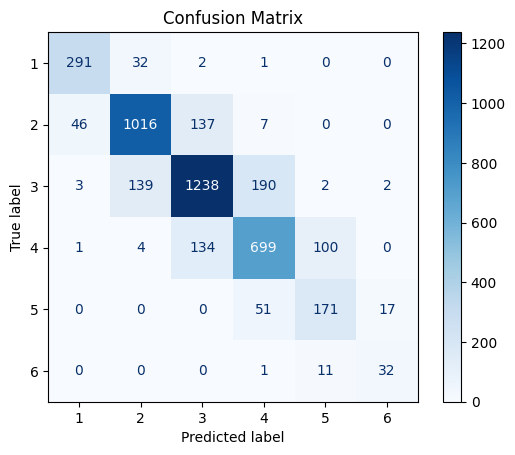

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate and display the confusion matrix for the test predictions
cm = confusion_matrix(y_true, predictions, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


In [55]:
# Identifying misclassified samples
misclassified_indices = (y_true != predictions)
misclassified_samples = val_features[misclassified_indices]
misclassified_true_labels = y_true[misclassified_indices]
misclassified_predicted_labels = predictions[misclassified_indices]


In [56]:
# Examining features of misclassified samples
import pandas as pd
misclassified_df = pd.DataFrame(misclassified_samples)
misclassified_df['True_Label'] = misclassified_true_labels
misclassified_df['Predicted_Label'] = misclassified_predicted_labels
# Display the first few rows of the misclassified samples
misclassified_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639,640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703,704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784,785,786,787,788,789,790,791,792,793,794,795,796,797,798,799,800,801,802,803,804,805,806,807,808,809,810,811,812,813,814,815,816,817,818,819,820,821,822,823,824,825,826,827,828,829,830,831,832,833,834,835,836,837,838,839,840,841,842,843,844,845,846,847,848,849,850,851,852,853,854,855,856,857,858,859,860,861,862,863,864,865,866,867,868,869,870,871,872,873,874,875,876,877,878,879,880,881,882,883,884,885,886,887,888,889,890,891,892,893,894,895,896,897,898,899,900,901,902,903,904,905,906,907,908,909,910,911,912,913,914,915,916,917,918,919,920,921,922,923,924,925,926,927,928,929,930,931,932,933,934,935,936,937,938,939,940,941,942,943,944,945,946,947,948,949,950,951,952,953,954,955,956,957,958,959,960,961,962,963,964,965,966,967,968,969,970,971,972,973,974,975,976,977,978,979,980,981,982,983,984,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016,1017,1018,1019,1020,1021

In [57]:
# # Feature importance from LightGBM
# feature_importance = best_model.feature_importance(importance_type='gain')
# feature_names = val_features.columns
# feature_importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': feature_importance
# })
# # Sort features by importance
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# print(feature_importance_df)


In [58]:
# Checking class distribution in the true labels
label_counts = pd.Series(y_true).value_counts()
print(label_counts)


3    1574
2    1206
4     938
1     326
5     239
6      44
Name: count, dtype: int64


In [59]:
# from sklearn.model_selection import GridSearchCV
# # Define the hyperparameters to tune
# param_grid = {
#     'learning_rate': [0.01, 0.05, 0.1],
#     'num_leaves': [31, 62, 128],
#     'n_estimators': [50, 100, 200]
# }
# grid_search = GridSearchCV(best_model, param_grid, scoring='', cv=5)
# grid_search.fit(val_features, val_labels)
# print("Best parameters:", grid_search.best_params_)


In [60]:
# Check LightGBM version
import lightgbm as lgb
print(lgb.__version__)


4.3.0


In [61]:
# # Ensure the model is fitted
# if not hasattr(best_model, 'feature_importance_'):
#     best_model.fit(val_features, val_labels)  # Train or re-train the model

# # Retrieve feature importance
# feature_importance = best_model.feature_importance_  # Underscore at the end
# feature_names = val_features.columns

# # Create DataFrame for feature importance
# feature_importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': feature_importance
# })
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# print(feature_importance_df)


In [62]:
# Assuming `df` is the original DataFrame and `predictions` is a list/array of predicted labels
# If there's a subset used for predictions, ensure it aligns with the DataFrame
val_df['Predicted_Label'] = predictions


/tmp/ipykernel_234919/2456578638.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  val_df['Predicted_Label'] = predictions


In [63]:
print(len(val_features), len(val_df), len(predictions))

4327 4327 4327


In [64]:
val_df.tail()

,essay_id,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,able,able to,about,about the,accidents,action,action coding,action coding system,actually,after,air,alien,aliens,all,all of,all the,also,always,amount,an,and,and it,and that,and the,and they,animals,another,any,anything,are,are not,around,article,as,as the,at,at the,atmosphere,attention,author,away,back,bad,be,be able,be able to,be the,because,because it,because of,because the,because they,become,been,before,being,believe,believe that,best,better,big,bored,but,but it,by,by the,called,can,can be,candidate,car,car usage,cars,cars are,cause,change,city,classroom,close,coding,coding system,college,college is,come,computer,computers,conclusion,conditions,confused,control,could,could be,country,cowboy,cowboys,created,dangerous,dangers,day,despite,did,different,do,do not,does,doing,don,dont,down,drive,driver,driverless,driverless car,driverless cars,driverless cars are,drivers,driving,due,due to,each,earth,election,electoral,electoral college,electoral college is,electors,emotion,emotions,enough,even,ever,every,everyone,evidence,example,exploring,expressions,face,face on,face on mars,facial,facial action,facial action coding,fact,feel,feeling,few,find,first,for,for example,for the,free,from,from the,fun,future,gas,get,get to,getting,give,go,going,going to,good,got,great,had,happen,happy,hard,has,has been,have,have been,have to,having,he,help,his,how,however,human,humans,idea,if,if the,if they,if we,if you,important,in,in conclusion,in our,in paragraph,in the,in the article,in this,information,into,is,is just,is not,is that,is the,is very,it,it can,it could,it is,it was,it will,it would,it would be,its,join,just,keep,know,landform,learn,less,lesson,life,like,limiting,live,long,look,lot,lot of,luke,made,make,makes,making,many,many people,mars,may,maybe,me,means,mesa,might,money,more,most,much,my,nasa,natural,natural landform,need,need to,needs,never,new,no,not,not be,not only,now,of,of the,of this,of venus,off,on,on earth,on mars,on the,once,one,one of,only,or,other,others,our,out,out of,over,own,paragraph,paris,people,percent,person,picture,place,places,planet,point,pollution,popular,popular vote,

In [65]:
# merge 'clean_text' column back with val df 

text = val_essays[['essay_id', 'clean_text']]

val_df = val_df.merge(text, on = 'essay_id')

val_df.head()

,essay_id,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,able,able to,about,about the,accidents,action,action coding,action coding system,actually,after,air,alien,aliens,all,all of,all the,also,always,amount,an,and,and it,and that,and the,and they,animals,another,any,anything,are,are not,around,article,as,as the,at,at the,atmosphere,attention,author,away,back,bad,be,be able,be able to,be the,because,because it,because of,because the,because they,become,been,before,being,believe,believe that,best,better,big,bored,but,but it,by,by the,called,can,can be,candidate,car,car usage,cars,cars are,cause,change,city,classroom,close,coding,coding system,college,college is,come,computer,computers,conclusion,conditions,confused,control,could,could be,country,cowboy,cowboys,created,dangerous,dangers,day,despite,did,different,do,do not,does,doing,don,dont,down,drive,driver,driverless,driverless car,driverless cars,driverless cars are,drivers,driving,due,due to,each,earth,election,electoral,electoral college,electoral college is,electors,emotion,emotions,enough,even,ever,every,everyone,evidence,example,exploring,expressions,face,face on,face on mars,facial,facial action,facial action coding,fact,feel,feeling,few,find,first,for,for example,for the,free,from,from the,fun,future,gas,get,get to,getting,give,go,going,going to,good,got,great,had,happen,happy,hard,has,has been,have,have been,have to,having,he,help,his,how,however,human,humans,idea,if,if the,if they,if we,if you,important,in,in conclusion,in our,in paragraph,in the,in the article,in this,information,into,is,is just,is not,is that,is the,is very,it,it can,it could,it is,it was,it will,it would,it would be,its,join,just,keep,know,landform,learn,less,lesson,life,like,limiting,live,long,look,lot,lot of,luke,made,make,makes,making,many,many people,mars,may,maybe,me,means,mesa,might,money,more,most,much,my,nasa,natural,natural landform,need,need to,needs,never,new,no,not,not be,not only,now,of,of the,of this,of venus,off,on,on earth,on mars,on the,once,one,one of,only,or,other,others,our,out,out of,over,own,paragraph,paris,people,percent,person,picture,place,places,planet,point,pollution,popular,popular vote,

In [66]:
# Assuming `df` has the original labels in a column named 'True_Label'
misclassified_samples = val_df[val_df['score'] != val_df['Predicted_Label']]

# Display misclassified samples
print(misclassified_samples[['score', 'Predicted_Label', 'clean_text']][:15])


    score  Predicted_Label                                         clean_text
0       3                2  many people have car where they live the thing...
7       2                1  in the text the author uses facts that people ...
10      2                3  limiting car use is a great way clean up green...
12      4                3  did you know that venus was maybe once like ea...
15      1                2  the author suggets that studying venus is a wo...
19      4                5  in the challenge of exploring venus the debate...
20      1                3  the face was dicovered on may it was discovere...
27      4                3  in the article the challenge of exploring venu...
28      4                5  fellow citizens there are many reasons why lim...
36      5                4  i believe that the facial action coding system...
39      2                3  the use of this technology to read the emotion...
40      3                2  the picture shows a face but how lon

In [67]:
# Example: Analyze original text of misclassified samples
misclassified_text = misclassified_samples['clean_text']  # Assuming 'Text' is the original text data
print(misclassified_text.head())


0     many people have car where they live the thing...
7     in the text the author uses facts that people ...
10    limiting car use is a great way clean up green...
12    did you know that venus was maybe once like ea...
15    the author suggets that studying venus is a wo...
Name: clean_text, dtype: object


In [68]:
# load tf model
len(misclassified_text)

880

In [69]:
# add full mis classified text to a txt file seperated by  '---' and a new line after every 10 words in each essay

with open('misclassified_text.txt', 'w') as f:
    for essay in misclassified_text:
        f.write("%s\n" % essay)
        f.write('---\n')
        


In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Assuming `df` has your model's features and labels
X = val_df[feature_cols]
y = val_df['score'] == val_df['Predicted_Label']

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a RandomForest to see feature importances
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Get the most important features
importances = clf.feature_importances_
features = feature_cols
important_features = {features[i]: importances[i] for i in range(len(features))}

# convert to percentages rounded and sort

important_features = {k: round(v, 5) for k, v in important_features.items()}

print("Most predictive features of misclassification:", sorted(important_features.items(), key=lambda x: x[1], reverse=True))

Most predictive features of misclassification: [('deberta_prob_2', 0.00581), ('deberta_prob_1', 0.00555), ('deberta_prob_3', 0.00387), ('deberta_prob_4', 0.00332), ('deberta_prob_0', 0.00297), ('pos_INTJ', 0.00232), ('time', 0.0023), ('hash_14', 0.00219), ('xlnet_prob_5', 0.00217), ('hash_30', 0.00217), ('would be', 0.00204), ('times', 0.00198), ('to drive', 0.00192), ('to see', 0.00185), ('to make', 0.00184), ('hash_33', 0.00182), ('hash_110', 0.00174), ('hash_175', 0.00172), ('too', 0.00169), ('hash_156', 0.00167), ('hash_62', 0.00165), ('hash_11', 0.00164), ('deberta_prob_5', 0.00163), ('would have', 0.00163), ('years', 0.00161), ('xlnet_prob_2', 0.0016), ('trying to', 0.00159), ('two', 0.00155), ('hash_196', 0.00152), ('get', 0.00152), ('hash_95', 0.00151), ('hash_188', 0.0015), ('hash_86', 0.00149), ('pos_PROPN', 0.00149), ('hash_29', 0.00148), ('hash_98', 0.00148), ('hash_162', 0.00148), ('pos_SPACE', 0.00148), ('xlnet_prob_1', 0.00147), ('xlnet_prob_0', 0.00146), ('hash_126', 0.

In [71]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Assume val_df and feature_cols are already defined

# # Set the option to display all rows
# pd.set_option('display.max_rows', None)

# # Selecting the features and the target
# X = val_df[feature_cols]
# y = val_df['score']

# # Calculate the correlation between features and the target
# corr = X.corrwith(y)

# # Sort the correlation values
# corr = corr.sort_values(ascending=False)

# # Convert the Series to a DataFrame for heatmap compatibility
# corr_df = pd.DataFrame(corr, columns=['Correlation'])

# corr_df


In [72]:
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report

# # Define the feature set with and without the specific features
# X_with = val_df[feature_cols]  # including all features
# X_without = val_df.drop(columns=['misspelling_count', 'sentence_length'], axis=1) # excluding problematic features

# y = val_df['score']  # target variable

# # Split the data
# X_train_with, X_test_with, y_train, y_test = train_test_split(X_with, y, test_size=0.3, random_state=42)
# X_train_without, X_test_without, _ , _ = train_test_split(X_without, y, test_size=0.3, random_state=42)

# # Train models
# model_with = RandomForestClassifier().fit(X_train_with, y_train)
# model_without = RandomForestClassifier().fit(X_train_without, y_train)

# # Evaluate models
# print("With features:")
# print(classification_report(y_test, model_with.predict(X_test_with)))

# print("Without features:")
# print(classification_report(y_test, model_without.predict(X_test_without)))
